Contemplating these chapters 

08 — Instrumental Variables <br>
09 — Non Compliance and LATE <br>
16 — Regression Discontinuity Design

In [12]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
import statsmodels.formula.api as smf
style.use("fivethirtyeight")
import os
os.getcwd()
os.chdir('/Users/hiro/Documents/github/Causal_Inference')

## Chapter 8: IV!!!

$$ log(wage)_i = \beta_0 + \kappa Educ_i + \beta Abil_i + u_i $$
$$ Y_i = \beta_0 + \kappa T_i + \beta W_i + u_i$$

But we can only run
$$ Y_i = \beta_0 + \kappa T_i + v_i$$


Need to control for ability, which is not observed. Use something 1) Relevant: Cov(W,Z) ≠ 0, and 2) Exogenous Cov(Z,v) = 0 

$Cov(Z,Y) = \kappa Cov(Z, T)$

$$\kappa = \frac{Cov(Z,Y)/Var(Z)}{Cov(Z,T)/Var(Z)} = \frac{\beta_{Y \sim Z}}{\beta_{T \sim Z}}$$
$$\kappa = \frac{\frac{\partial Y}{\partial Z}}{\frac{\partial T}{\partial Z}} = \frac{\partial Y}{\partial Z} \times \frac{\partial Z}{\partial T} = \frac{\partial Y}{\partial T}$$

$$ log(wage)_i = \beta_0 + \kappa Educ_i + \beta Abil_i + u_i $$
$$ Cov(Educ_i, Quarter\_birth) ≠ 0  + log(wage) \perp Quarter\_birth | Educ$$

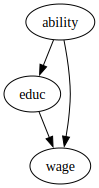

In [13]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import graphviz as gr
from linearmodels.iv import IV2SLS

%matplotlib inline

pd.set_option("display.max_columns", 5)
style.use("fivethirtyeight")

g = gr.Digraph()

g.edge("ability", "educ")
g.edge("ability", "wage")
g.edge("educ", "wage")
g

In [ ]:
data = pd.read_csv("./data/ak91.csv")
data.head()

group_data = (data
              .groupby(["year_of_birth", "quarter_of_birth"])
              [["log_wage", "years_of_schooling"]]
              .mean()
              .reset_index()
              .assign(time_of_birth = lambda d: d["year_of_birth"] + (d["quarter_of_birth"])/4))

plt.figure(figsize=(15,6))
plt.plot(group_data["time_of_birth"], group_data["years_of_schooling"], zorder=-1)
for q in range(1, 5):
    x = group_data.query(f"quarter_of_birth=={q}")["time_of_birth"]
    y = group_data.query(f"quarter_of_birth=={q}")["years_of_schooling"]
    plt.scatter(x, y, marker="s", s=200, c=f"C{q}")
    plt.scatter(x, y, marker=f"${q}$", s=100, c=f"white")

plt.title("Years of Education by Quarter of Birth (first stage)")
plt.xlabel("Year of Birth")
plt.ylabel("Years of Schooling");

factor_data = data.assign(**{f"q{int(q)}": (data["quarter_of_birth"] == q).astype(int)
                             for q in data["quarter_of_birth"].unique()})

factor_data.head()

first_stage = smf.ols("years_of_schooling ~ C(year_of_birth) + C(state_of_birth) + q4", data=factor_data).fit()

print("q4 parameter estimate:, ", first_stage.params["q4"])
print("q4 p-value:, ", first_stage.pvalues["q4"])

plt.figure(figsize=(15,6))
plt.plot(group_data["time_of_birth"], group_data["log_wage"], zorder=-1)
for q in range(1, 5):
    x = group_data.query(f"quarter_of_birth=={q}")["time_of_birth"]
    y = group_data.query(f"quarter_of_birth=={q}")["log_wage"]
    plt.scatter(x, y, marker="s", s=200, c=f"C{q}")
    plt.scatter(x, y, marker=f"${q}$", s=100, c=f"white")

plt.title("Average Weekly Wage by Quarter of Birth (reduced form)")
plt.xlabel("Year of Birth")
plt.ylabel("Log Weekly Earnings");

reduced_form = smf.ols("log_wage ~ C(year_of_birth) + C(state_of_birth) + q4", data=factor_data).fit()

print("q4 parameter estimate:, ", reduced_form.params["q4"])
print("q4 p-value:, ", reduced_form.pvalues["q4"])

reduced_form.params["q4"] / first_stage.params["q4"] #0.08530286492085315 #This means that we should expect each additional year of school to increase wages by 8%.

#ALTERNATIVELY, WE COULD DO IT BY HAND
iv_by_hand = smf.ols("log_wage ~ C(year_of_birth) + C(state_of_birth) + years_of_schooling_fitted",
                     data=factor_data.assign(years_of_schooling_fitted=first_stage.fittedvalues)).fit()

iv_by_hand.params["years_of_schooling_fitted"] #0.0853028649208674 #As you can see, the parameters are exactly the same. #In practice, however, we don’t do IV by hand.


#Using linearmodels!
def parse(model, exog="years_of_schooling"):
    param = model.params[exog]
    se = model.std_errors[exog]
    p_val = model.pvalues[exog]
    print(f"Parameter: {param}")
    print(f"SE: {se}")
    print(f"95 CI: {(-1.96*se,1.96*se) + param}")
    print(f"P-value: {p_val}")
    
formula = 'log_wage ~ 1 + C(year_of_birth) + C(state_of_birth) + [years_of_schooling ~ q4]'
iv2sls = IV2SLS.from_formula(formula, factor_data).fit()
parse(iv2sls)

#Using multiple instruments
formula = 'log_wage ~ 1 + C(year_of_birth) + C(state_of_birth) + [years_of_schooling ~ q1+q2+q3]'
iv_many_zs = IV2SLS.from_formula(formula, factor_data).fit()
parse(iv_many_zs) #With all 3 dummies, the estimated return on education is now 0.1, which means that we should expect a 10% average increase on earnings for every additional year of education.

formula = "log_wage ~ years_of_schooling + C(state_of_birth) + C(year_of_birth) + C(quarter_of_birth)"
ols = IV2SLS.from_formula(formula, data=data).fit()
parse(ols) #The return on education is estimated to be lower with OLS than with 2SLS. #notice the confidence intervals. 2SLS has a much wider CI than the OLS estimate.

q4 parameter estimate:,  0.10085809272784482
q4 p-value:,  5.464829416657389e-15
q4 parameter estimate:,  0.008603484260145622
q4 p-value:,  0.0014949127183541374
Parameter: 0.0853028649580665
SE: 0.02554081280862408
95 CI: [0.03524287 0.13536286]
P-value: 0.0008381914596313766


IV: estimate ATE indirectly.
If impact of treatment on the outcome strong, then 2nd stage strong -> but problem if first-stage instrument weak (small correlation)

In [ ]:

np.random.seed(12)
n = 10000
X = np.random.normal(0, 2, n) # observable variable
U = np.random.normal(0, 2, n) # unobservable (omitted) variable
T = np.random.normal(1 + 0.5*U, 5, n) # treatment
Y = np.random.normal(2 + X - 0.5*U + 2*T, 5, n) # outcome

stddevs = np.linspace(0.1, 100, 50)
Zs = {f"Z_{z}": np.random.normal(T, s, n) for z, s in enumerate(stddevs)} # instruments with decreasing \mathrm{Cov}(Z, T)

sim_data = pd.DataFrame(dict(U=U, T=T, Y=Y)).assign(**Zs)

sim_data.head()

corr = (sim_data.corr()["T"]
        [lambda d: d.index.str.startswith("Z")])

corr.head()

se = []
ate = []
for z in range(len(Zs)):
    formula = f'Y ~ 1 + X + [T ~ Z_{z}]'
    iv = IV2SLS.from_formula(formula, sim_data).fit()
    se.append(iv.std_errors["T"])
    ate.append(iv.params["T"])


plot_data = pd.DataFrame(dict(se=se, ate=ate, corr=corr)).sort_values(by="corr")

plt.scatter(plot_data["corr"], plot_data["se"])
plt.xlabel("Corr(Z, T)")
plt.ylabel("IV Standard Error");
plt.title("Variance of the IV Estimates by 1st Stage Strength");

plt.scatter(plot_data["corr"], plot_data["ate"])
plt.fill_between(plot_data["corr"],
                 plot_data["ate"]+1.96*plot_data["se"],
                 plot_data["ate"]-1.96*plot_data["se"], alpha=.5)
plt.xlabel("Corr(Z, T)")
plt.ylabel("$\hat{ATE}$");
plt.title("IV ATE Estimates by 1st Stage Strength");

Estimates vary wildly when the $cov(T,Z)$ is weak. SE increases when cov low.

Another thing to notice is that 2SLS is biased! Even with high correlation, the parameter estimate still does not reach the true ATE of 2.0. Actually, 2.0 is not even in the 95% CI! 2SLS is only consistent, which means that it approaches the true parameter value if the sample size is big enough. However, we can’t know how big is big enough. We can only stick to some rules of thumb to understand how this bias behaves:

2SLS is biased towards OLS. This means that if OLS has a negative/positive bias, 2SLS will also have it. The advantage of 2SLS is that it is at least consistent, where OLS is not, in the case of omitted variables. In the example above, our unobserved U impacts negatively the outcome but its positively correlated with the treatment, which will result in a negative bias. That is why we are seeing the ATE estimate below the true value (negative bias).

The bias will increase with the number of instruments we add. If we add too many instruments, 2SLS becomes more and more like OLS.

Besides knowing how this bias behaves, a final piece of advice is to avoid some common mistakes when doing IV:

1. Doing IV by hand. As we’ve seen, IV by hand will result in wrong standard errors, even if the parameter estimates are right. The SE won’t be completely off. Still, why do it if you can use software and get the right SE?

2. Using anything other than OLS on the 1st stage. Lots of Data Scientist encounter IV and think they can do better. For example, they see a dummy treatment and think about replacing the 1st stage by a logistic regression, after all, they are predicting a dummy variable, right?. The problem is that this is plain wrong. The consistency of IV relies on a property that only OLS can give, which is the orthogonality of the residuals, so anything different than OLS on the 1st stage will yield something biased. (OBS: there are some modern techniques that use Machine Learning for IV, but their results have been, at best, questionable).

## Chapter 9:

Boost user engagement: measured by in app purchase. Come up with a push you can use to engage your users. With that push, you move on to design a randomised trial. You select 10000 random customers and, for each of them, you assign the push with 50% probability. However, when you execute the test, you notice that some customers who were assigned to receive the push are not receiving it. It is because they probably have an older phone that doesn’t support the kind of push the marketing team designed.

We want 
$$ATE = E[Y|Push\_Assigned = 1] - E[Y|Push\_Assigned = 0]$$

The causal effect of treatment assignment is biased towards zero because non compliance shrinks the detectable impact.

$$Potential Outcome = \begin{cases} Y_i(1,1), \text{ if } T_i = 1, Z_i = 1 \\ Y_i(1,0), \text{ if } T_i = 1, Z_i = 0 \\ Y_i(0,1), \text{ if } T_i = 0, Z_i = 1 \\ Y_i(0,0), \text{ if } T_i = 0, Z_i = 0 \end{cases}$$

$Z$ is assignment "doctor prescribes drug", $T$ is treatment "patient actually takes it".

$$Potential Treatment = \begin{cases} T_0 \text{ if }Z_i = 0 \\ T_1 \text{ if }Z_i = 1 \end{cases}$$

$$Z \to T \to Y$$

IV Assumptions:
1. Independence: Instrument Z is randomly assigned, $T_{0i}, T_{1i} \perp Z_i$ and $Y_i(T_{1i}, 1), Y_i(T_{0i},0)\perp Z_i$
2. Exclusion: $Y_i(1,1) = Y_i(1,0) = Y_{i1}$ and $Y_{i}(0,0) = Y_i(0,1) = Y_{i0}$
3. Instrument affects treatment: $E[T_{i1}] \neq E[T_{i0}]$ doctor prescribing drug actually affects whether the patient takes or not
4. Monotonicity: $T_{i1} > T_{i0}$ treatment level higher if assigned then not.



$$ATE = \frac{E[Y|Z = 1] - E[Y| Z = 0]}{E[T|Z=1] - E[T|Z=0]} = \frac{\text{Effect of assignment}}{\text{Effect of treatment}}$$

$$ATE = E[(Y_{i1}-Y_{i0})|T_{i1}>T_{i0}]$$

Because:
$$E[Y_i|Z_i = 1] = E[Y_{i0} + T_{i1}(Y_{i1}-Y_{i0})|Z=1]  \stackrel{\text{Indep}}{=} E[Y_{i0} + T_{i1}(Y_{i1}-Y_{i0})]$$

$$E[Y_i|Z_i = 1] - E[Y_i|Z_i = 0] \stackrel{\text{By above}}{=} E[(Y_{i1}-Y_{i0})(T_{i1}-T_{i0})]$$
$$E[(Y_{i1}-Y_{i0})(T_{i1}-T_{i0})] = E[(Y_{i1}-Y_{i0})|T_{i1} > T_{i0}]P(T_{i1} > T_{i0}) $$
$$E[T|Z = 1] - E[T|Z = 0] \stackrel{\text{By def}}{=} E[T_{i1} - T_{i0}] \stackrel{\text{T is 0 or 1}}{=} P(T_{i1} > T_{i0})$$

Compliers: $T_{i1} > T_{i0}$
Never Takers $T_{i1} = T_{i0} = 0$
Always Takers $T_{i1} = T_{i0} = 1$

In [ ]:
data = pd.read_csv("./data/app_engagement_push.csv")
    
data.head()

ols = IV2SLS.from_formula("in_app_purchase ~ 1 + push_assigned + push_delivered", data).fit()
ols.summary.tables[1]

In [ ]:
reduced_form = IV2SLS.from_formula("in_app_purchase ~ 1 + push_assigned", data).fit()
reduced_form.summary.tables[1]

In [ ]:
iv = IV2SLS.from_formula("in_app_purchase ~ 1 + [push_delivered ~ push_assigned]", data).fit()
iv.summary.tables[1]

## Chapter 16: Regression Discontinuity Design
Treatment $T$ is a discontinuous function of observed _running variable_ $R$:
$$T_i = 1\{R_i>c\}$$

So,

$$Y = \begin{cases} Y_0 \text{ if }R_i > c\\ Y_1 \text{ otherwise } \end{cases}$$

RDD Smoothness Assumption
$$\lim_{r \to c^{-}} E[Y_{ti}|R_{i} = r] = \lim_{r \to c^{+}} E[Y_{ti}|R_{i} = r]$$

Which means: Local Avg. Trt. Effect (only at the threshold)
$$\lim_{r \to c^{-}} E[Y_{ti}|R_{i} = r] - \lim_{r \to c^{+}} E[Y_{ti}|R_{i} = r] = E[Y_{1i}-Y_{0i}|R_i = r]$$

Estimation:
$$y_i = \beta_0 + \beta_1 r_i + \beta_2 1\{r_i > c\} + \beta_3 1 \{r_i > c\}r_i$$

$$y_i = \begin{cases} (\beta_0 + \beta_2) + (\beta_1 + \beta_3) r_i \text{ if }r_i > c \\ \beta_0 + \beta_1 r_i \text{ otherwise. }   \end{cases}$$


Center the variables! Then $\beta_2$ is the LATE

In [ ]:
drinking = pd.read_csv("./data/drinking.csv")
drinking.head()[["agecell", "all", "mva", "suicide"]]

rdd_df = drinking.assign(threshold=(drinking["agecell"] > 0).astype(int))
model = smf.wls("all~agecell*threshold", rdd_df).fit()
model.summary().tables[1]

ax = drinking.plot.scatter(x="agecell", y="all", color="C0")
drinking.assign(predictions=model.fittedvalues).plot(x="agecell", y="predictions", ax=ax, color="C1")
plt.title("Regression Discontinuity");